**Early Predictors of Startup Growth**

**Introduction**

The startup ecosystem has grown rapidly, but early-stage success remains difficult to predict. While many startups secure initial funding, only a small proportion progress to major milestones such as Series A funding. 

This project explores whether early-stage indicators — such as funding activity and investor involvement - are associated with startup growth.

**Research Question**

Which early-stage characteristics are associated with progression to a Series A funding round?

**Hypotheses**

*H1:* Larger founding teams are associated with Series A progression

*H2:* Higher early funding is associated with Series A progression

*H3:* More funding rounds are associated with Series A progression

*H4:* More investors are associated with Series A progression

**Data and Methodology**

This analysis uses 2 startup datasets:
- Startup profile dataset
- Funding events dataset

The data was cleaned, standardized, and merged using startup names.

Key variables were engineered to represent early-stage characteristics and Series A outcomes.

In [26]:
# Load the libraries #
import pandas as pd

In [2]:
# Load both datasets #
inv = pd.read_csv('Investors_DS1.csv')
fund = pd.read_csv('Startups_funding_DS2.csv')

print("=== Investors_DS1 - (inv) head ===")
print(inv.head())

print("\n=== Investors_DS1 - (inv) columns ===")
print(inv.columns)

print("=== Startups_funding_DS2 - (fund) head ===")
print(fund.head())

print("\n= Startups_funding_DS2 - (fund) column ===")
print(fund.columns)

=== Investors_DS1 - (inv) head ===
         Company       City  Starting Year  \
0  Urban Company    Gurgaon           2014   
1      Classplus      Noida           2018   
2          Paytm      Noida           2010   
3           Apna     Mumbai           2019   
4       Razorpay  Bengaluru           2014   

                                            Founders  \
0  Abhiraj Singh Bhal, Raghav Chandra, Varun Khaitan   
1  Bhaswat Agarwal, Bikash Dash, Mukul Rustagi, N...   
2                Akshay Khanna, Vijay Shekhar Sharma   
3                                      Nirmit Parikh   
4                     Harshil Mathur, Shashank Kumar   

                                          Industries  \
0  Apps, Home Services, Marketplace, Service Indu...   
1  B2B, E-Learning, EdTech, Education, Mobile App...   
2  E-Commerce, Finance, Financial Services, Inter...   
3  Employment, Human Resources, Recruiting, Staff...   
4    Financial Services, FinTech, Payments, Software   

              

**Data Cleaning**

Data preprocessing included:
- Standardized startup names
- Removing unneccessary columns
- Handling missing values
- Formatting text-based fields.

In [3]:
# Drop unnecessary index-like columns from funding dataset #
fund = fund.drop(columns=['Unnamed: 0', 'Sr No'])

In [4]:
# Normalize Startup Names #
inv['Company_clean'] = inv['Company'].str.lower().str.strip()
fund['startup_clean'] = fund['startup'].str.lower().str.strip()

print("=== Sample of cleaned names from inv ===")
print(inv[['Company','Company_clean']].head())

print("=== Sample of cleaned names from fund ===")
print(fund[['startup','startup_clean']].head())

=== Sample of cleaned names from inv ===
         Company  Company_clean
0  Urban Company  urban company
1      Classplus      classplus
2          Paytm          paytm
3           Apna           apna
4       Razorpay       razorpay
=== Sample of cleaned names from fund ===
     startup startup_clean
0      #Fame         #fame
1        1mg           1mg
2  20Dresses     20dresses
3  33Coupons     33coupons
4    6Degree       6degree


**Feature Engineering**

New variables were created to quantify early-stage characteristics:

- founders_count: number of founders per startup
- num_funding_rounds: total number of funding rounds
- early_total_funding: total early funding amount
- unique_investors_count: number of unique investors
- SeriesA_flag: indicates whether a startup reached Series A

In [5]:
# Clean founders column and extract founder_count properly #
inv['Founders_clean'] = inv['Founders'].astype(str).str.replace('\n',' ', regex=True).str.strip()

inv['founders_count'] = inv['Founders_clean'].apply(lambda x: len([f for f in x.split(',') if f.strip() != '']))

print(inv[['Company','Founders_clean','founders_count']].head())

         Company                                     Founders_clean  \
0  Urban Company  Abhiraj Singh Bhal, Raghav Chandra, Varun Khaitan   
1      Classplus  Bhaswat Agarwal, Bikash Dash, Mukul Rustagi, N...   
2          Paytm                Akshay Khanna, Vijay Shekhar Sharma   
3           Apna                                      Nirmit Parikh   
4       Razorpay                     Harshil Mathur, Shashank Kumar   

   founders_count  
0               3  
1               5  
2               2  
3               1  
4               2  


In [6]:
# Create Series A Flag #
fund['SeriesA_flag'] = fund['round'].apply(lambda x: 1 if 'Series A' in str(x) else 0)

# Reduce to startup level: if ANY round is Series A -> 1 #
seriesA = fund.groupby('startup_clean')['SeriesA_flag'].max().reset_index()

In [7]:
# Merge investor dataset with Series A table #
merged = inv.merge(seriesA, left_on='Company_clean', right_on='startup_clean', how='left')

merged['SeriesA_flag'] = merged['SeriesA_flag'].fillna(0)

print(merged[['Company','Company_clean','founders_count','SeriesA_flag']].head())

         Company  Company_clean  founders_count  SeriesA_flag
0  Urban Company  urban company               3           0.0
1      Classplus      classplus               5           0.0
2          Paytm          paytm               2           0.0
3           Apna           apna               1           0.0
4       Razorpay       razorpay               2           0.0


In [11]:
# Feature engineering for early funding indicators

# Number of funding rounds per startup
fund_rounds = fund.groupby('startup_clean')['round'].count().reset_index()
fund_rounds.columns = ['startup_clean', 'num_funding_rounds']

# Total early funding amount per startup
fund_amount = fund.groupby('startup_clean')['amount'].sum().reset_index()
fund_amount.columns = ['startup_clean', 'early_total_funding']

# Number of unique investors
fund['investors_clean'] = fund['investors'].fillna('').astype(str).str.replace('\n', ' ', regex=True)

fund['investor_list'] = fund['investors_clean'].apply(
    lambda x: [i.strip() for i in x.split(',') if i.strip() != '']
)

unique_inv = fund.explode('investor_list')
unique_inv = unique_inv[unique_inv['investor_list'] != '']

unique_inv = unique_inv.groupby('startup_clean')['investor_list'].nunique().reset_index()
unique_inv.columns = ['startup_clean', 'unique_investors_count']

In [12]:
# Merge all engineered features into the main dataset #
merged = merged.merge(fund_rounds, on='startup_clean', how='left')
merged = merged.merge(fund_amount, on='startup_clean', how='left')
merged = merged.merge(unique_inv, on='startup_clean', how='left')

# Filling in the missing values #
merged[['num_funding_rounds','early_total_funding','unique_investors_count']] = \
merged[['num_funding_rounds', 'early_total_funding', 'unique_investors_count']].fillna(0)

In [13]:
merged.to_csv("startup_master_dataset.csv", index=False)

In [14]:
merged.head()
merged.info()
merged.describe()
merged['SeriesA_flag'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company                 300 non-null    str    
 1   City                    300 non-null    str    
 2   Starting Year           300 non-null    int64  
 3   Founders                300 non-null    str    
 4   Industries              300 non-null    str    
 5   Description             300 non-null    str    
 6   No. of Employees        300 non-null    str    
 7   Funding Amount in $     300 non-null    str    
 8   Funding Round           300 non-null    int64  
 9   No. of Investors        300 non-null    int64  
 10  Company_clean           300 non-null    str    
 11  Founders_clean          300 non-null    str    
 12  founders_count          300 non-null    int64  
 13  startup_clean           198 non-null    str    
 14  SeriesA_flag            300 non-null    float64
 15  

SeriesA_flag
0.0    284
1.0     16
Name: count, dtype: int64

**Exploratory Data Analysis**

This section explores the dataset to identify patterns between early-stage variables and Series A outcomes.

In [15]:
# Basic EDA on final merged dataset #

In [16]:
# Structure of dataset #
print("=== Dataset Info ===")
print(merged.info())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company                 300 non-null    str    
 1   City                    300 non-null    str    
 2   Starting Year           300 non-null    int64  
 3   Founders                300 non-null    str    
 4   Industries              300 non-null    str    
 5   Description             300 non-null    str    
 6   No. of Employees        300 non-null    str    
 7   Funding Amount in $     300 non-null    str    
 8   Funding Round           300 non-null    int64  
 9   No. of Investors        300 non-null    int64  
 10  Company_clean           300 non-null    str    
 11  Founders_clean          300 non-null    str    
 12  founders_count          300 non-null    int64  
 13  startup_clean           198 non-null    str    
 14  SeriesA_flag            300 non-

In [17]:
# Summary Statistics #
print("=== Summary Statistics ===")
print(merged.describe(include='all'))

=== Summary Statistics ===
              Company       City  Starting Year       Founders  \
count             300        300     300.000000            300   
unique            300         24            NaN            288   
top     Urban Company  Bengaluru            NaN  Not Available   
freq                1        123            NaN              9   
mean              NaN        NaN    2013.393333            NaN   
std               NaN        NaN       5.139390            NaN   
min               NaN        NaN    1984.000000            NaN   
25%               NaN        NaN    2012.000000            NaN   
50%               NaN        NaN    2015.000000            NaN   
75%               NaN        NaN    2016.000000            NaN   
max               NaN        NaN    2020.000000            NaN   

                           Industries  \
count                             300   
unique                            290   
top     E-Learning, EdTech, Education   
freq            

In [18]:
# Count of series A vs non Series A startups #
print("=== Series A Distribution ===")
print(merged['SeriesA_flag'].value_counts())

=== Series A Distribution ===
SeriesA_flag
0.0    284
1.0     16
Name: count, dtype: int64


In [19]:
print("=== Series A Percentage ===")
print(merged['SeriesA_flag'].value_counts(normalize=True) * 100)

=== Series A Percentage ===
SeriesA_flag
0.0    94.666667
1.0     5.333333
Name: proportion, dtype: float64


In [20]:
# Quick checks of predictor variables #
print("=== Sample Early Indicators ===")
print(merged.groupby('SeriesA_flag')[['founders_count',
                                      'num_funding_rounds',
                                      'early_total_funding',
                                      'unique_investors_count']].head())

=== Sample Early Indicators ===
    founders_count  num_funding_rounds  early_total_funding  \
0                3                 0.0                 0.00   
1                5                 3.0               918.00   
2                2                 8.0              8072.84   
3                1                 0.0                 0.00   
4                2                 6.0               489.24   
26               1                 1.0                41.25   
36               1                 3.0               141.57   
77               3                 4.0               299.52   
81               3                 5.0               476.25   
91               1                 8.0               238.86   

    unique_investors_count  
0                      0.0  
1                      5.0  
2                      9.0  
3                      0.0  
4                      8.0  
26                     1.0  
36                     2.0  
77                     6.0  
81           

In [21]:
# Grouped means (useful for findings) #
print("=== Grouped Means by Series A Outcome ===")
print(merged.groupby('SeriesA_flag')[['founders_count',
                                      'num_funding_rounds',
                                      'early_total_funding',
                                      'unique_investors_count']].mean())

=== Grouped Means by Series A Outcome ===
              founders_count  num_funding_rounds  early_total_funding  \
SeriesA_flag                                                            
0.0                 2.348592            2.257042           827.719049   
1.0                 2.687500            4.562500           352.008125   

              unique_investors_count  
SeriesA_flag                          
0.0                         3.549296  
1.0                         5.812500  


In [22]:
# Creating visuals that can be put in findings #

# Color Palette
import matplotlib.pyplot as plt

COLOR_NO_A = "#1F2933" # dark charcoal
COLOR_A = "#0D9488" # muted teal
BG_COLOR = "F7FCFE" # background color

labels = ["No Series A", "Series A"]
colors = [COLOR_NO_A, COLOR_A]

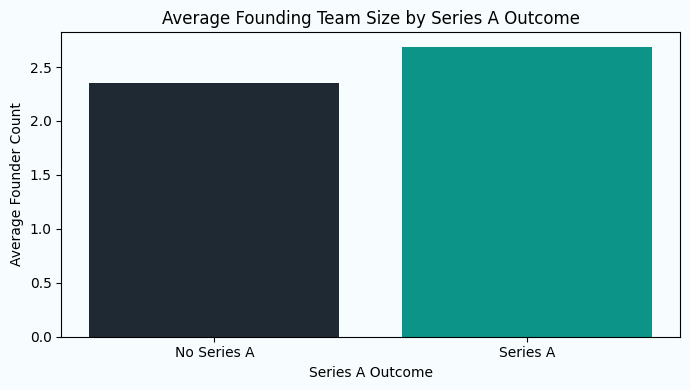

In [23]:
import matplotlib.pyplot as plt

# Redefine BG_COLOR with the correct hex prefix for this cell's execution
BG_COLOR = "#F7FCFE" # background color

# Bar Chart - H1: Founder Count vs Series A #
fig, ax = plt.subplots(figsize = (7,4), facecolor = BG_COLOR)
ax.set_facecolor(BG_COLOR)

values = (
    merged.groupby("SeriesA_flag")["founders_count"]
    .mean()
    .reindex([0,1])
)

ax.bar(labels, values, color = colors)
ax.set_title("Average Founding Team Size by Series A Outcome")
ax.set_xlabel("Series A Outcome")
ax.set_ylabel("Average Founder Count")

plt.tight_layout()
plt.show()

/var/folders/9h/81bggl5s1c5d9ckthkpkt8180000gn/T/ipykernel_64647/1579337126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


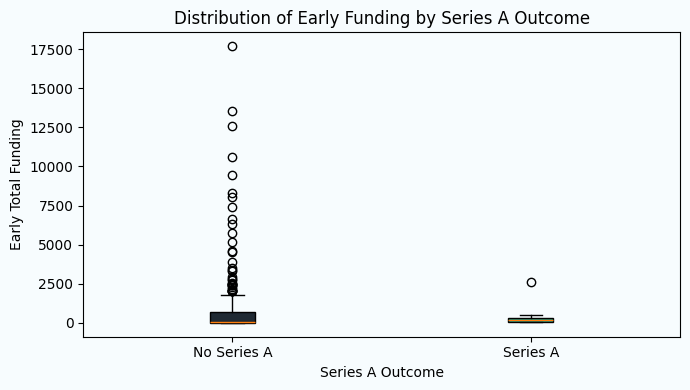

In [24]:
# Boxplot - H2: Early Total Funding vs Series A #
fig, ax = plt.subplots(figsize = (7,4), facecolor = BG_COLOR)
ax.set_facecolor(BG_COLOR)

data = [
    merged[merged["SeriesA_flag"] == 0]["early_total_funding"].dropna(),
    merged[merged["SeriesA_flag"] == 1]["early_total_funding"].dropna()
]

box = ax.boxplot(
    data,
    patch_artist=True,
    labels=["No Series A", "Series A"]
)

box["boxes"][0].set_facecolor(COLOR_NO_A)
box["boxes"][1].set_facecolor(COLOR_A)

ax.set_title("Distribution of Early Funding by Series A Outcome")
ax.set_xlabel("Series A Outcome")
ax.set_ylabel("Early Total Funding")

plt.tight_layout()
plt.show()

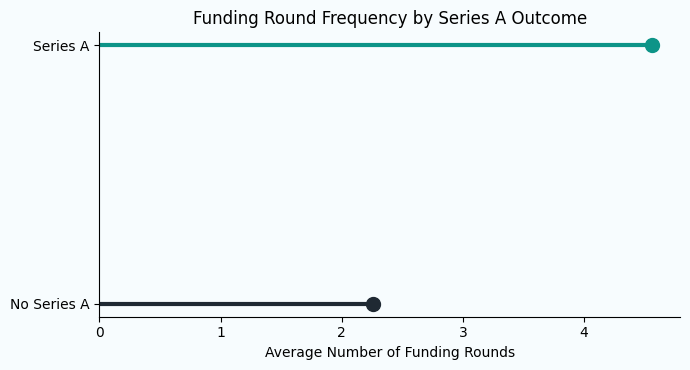

In [25]:
# Lollipop Stems + Dots - Number of Funding Rounds vs Series A #
vals = (
    merged.groupby("SeriesA_flag")["num_funding_rounds"]
    .mean()
    .reindex([0,1])
    .values
)

y_pos = [0,1]

fig, ax = plt.subplots(figsize = (7,3.8), facecolor = BG_COLOR)
ax.set_facecolor(BG_COLOR)

for y, v, c, in zip(y_pos, vals, colors):
  ax.hlines(y=y, xmin=0, xmax=v, color=c, linewidth=3) # stem
  ax.plot(v,y,"o",color=c, markersize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Average Number of Funding Rounds")
ax.set_title("Funding Round Frequency by Series A Outcome")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

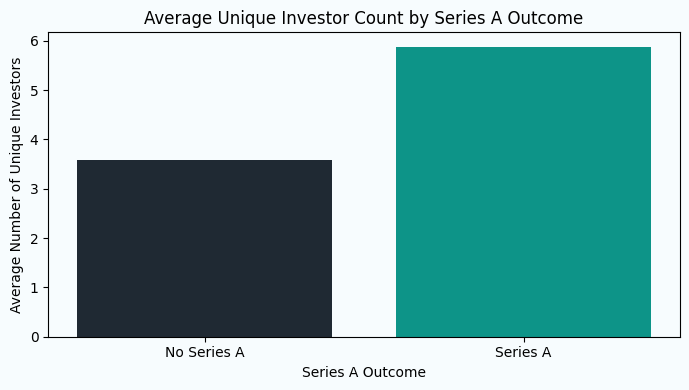

In [ ]:
# Bar Chart - H4: Unique Investors vs Series A #
fig, ax = plt.subplots(figsize = (7,4), facecolor = BG_COLOR)
ax.set_facecolor(BG_COLOR)

values = (
    merged.groupby("SeriesA_flag")["unique_investors_count"]
    .mean()
    .reindex([0,1])
)

ax.bar(labels, values, color=colors)
ax.set_title("Average Unique Investor Count by Series A Outcome")
ax.set_xlabel("Series A Outcome")
ax.set_ylabel("Average Number of Unique Investors")

plt.tight_layout()
plt.show()

**Analysis and Results**

- Startups that reached Series A generally raised more early funding
- They participated in more funding rounds
- They attracted a higher number of unique investors
- Founding team size showed a weaker association

Overall, funding-related and investor-related variables showed the strongest relationship with Series A progression.

**Discussion**

The results suggest that early financial traction and investor engagement are stronger indicators of startup growth than internal characteristics such as team size.

These findings support the idea that external validation plays a role in early-stage sources.

**Limitations**

- The dataset is limited in size and may not capture full funding histories
- The number of startups reaching Series A is relatively small
- Some variables were approximated using available data
- Geographic analysis was not possible due to missing data

**Conclusion**

Early-stage funding activity and investor involvement are the strongest indicators associated with progression to Series A.

These findings highlight the importance of external validation and financial momentum in early startup growth.